# 🌱 Deep Learning for Soil and Crop Recommendation

### 📖 **Table of Contents**    

- **1️⃣ | Introduction** → Background • Project Scope  
- **2️⃣ | EDA** → Dataset Overview • Data Insepection • Datat Cleaning • Data Visualization
- **3️⃣ | Model** → Model Selection
- **4️⃣ | Results** → Performance • Model Comparison • Analysis  
- **5️⃣ | Conclusion** → Findings • Challenges • Future
- **6️⃣ | Deliverables** → GitHub
- **7️⃣ | Reference**

---
---

### **1️⃣ | Introduction**

#### **1.1 Background**

Agriculture plays a crucial role in ensuring food security and economic stability worldwide. However, optimizing crop selection based on soil characteristics and environmental conditions remains a significant challenge for farmers. Soil properties such as pH, moisture content, and temperature directly influence plant growth and yield. Understanding these variables can help in precision agriculture, improving productivity while minimizing resource wastage.

Traditional methods for crop selection rely on manual experience and generalized guidelines, which may not account for variations in soil conditions. With the increasing availability of agricultural data and machine learning techniques, there is an opportunity to analyze soil attributes and uncover hidden patterns that can assist in data-driven decision-making for crop recommendation.


#### **1.2 Project Scope**

This project focuses on analyzing soil data using unsupervised learning techniques to identify patterns and relationships within key soil properties, including Soil pH, Moisture, Temperature, and Nutrient Composition (Nitrogen, Phosphorus, Potassium, etc.). By leveraging clustering algorithms such as K-Means and DBSCAN, along with dimensionality reduction techniques like PCA, this study aims to uncover hidden structures within the data to enhance crop recommendation and soil health assessment. The analysis will include exploratory data analysis (EDA), clustering, and anomaly detection to classify soil types and evaluate their potential agricultural applications.

The final deliverables will include detailed visualizations, analytical reports, and a well-documented GitHub repository. The insights from this study will contribute to precision farming strategies, enabling farmers to make informed crop selection decisions based on scientific soil analysis, which can lead to higher yields, sustainable land use, and more efficient resource management. While this study does not directly predict crop yields, it provides valuable data-driven insights to support smarter, more sustainable farming practices.

### **2️⃣ | Exploratory Data Analysis (EDA)**  

#### **2.1 Data Overview**  

This dataset contains 2200 entries with key soil and environmental features, including Nitrogen, Phosphorus, Potassium (NPK), Temperature, Humidity, pH, and Rainfall, along with a crop label indicating the best-suited crop for each soil profile. Before applying unsupervised learning, we need to inspect and clean the data. Two unnamed columns contain no values and will be removed. All essential features have valid data types, but we will check for duplicates, outliers, and correlations to ensure consistency.

A summary of the dataset shows high variability in nutrient levels, temperature ranging from 8.8°C to 43.7°C, humidity between 14.2% and 99.9%, and pH values from 3.5 (acidic) to 9.9 (alkaline), indicating diverse soil conditions. To explore patterns, we will use histograms, boxplots, scatterplots, and a correlation heatmap to visualize feature distributions and relationships. This will help in identifying clusters of similar soil types and anomalies that could influence model performance.

Finally, the data will be prepared by removing unnecessary columns, normalizing key features if needed, and ensuring a clean dataset for clustering. The insights gained from EDA will be essential for understanding soil diversity and making data-driven crop recommendations based on soil properties and environmental factors.

The dataset is clean, with 2,200 entries and no missing values. Now, I'll proceed with the following steps:

Separate features (X) and labels (y).
Encode the crop labels since unsupervised learning doesn't use explicit labels.
Split the data into training and testing sets (80% train, 20% test).

#### **2.2 Data Inspection**

The Data Inspection and Insertion step is essential for understanding the dataset before applying machine learning. Here, we load the dataset, check its structure using df.info(), and inspect the first few rows with df.head(). To analyze feature distributions, df.describe() provides summary statistics, highlighting variations in soil properties such as NPK, pH, temperature, humidity, and rainfall. This step ensures data quality and prepares it for further preprocessing and clustering analysis.

In [ ]:
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')
import torch
import torch.nn as nn 
import torch
import torch.nn as nn
import torch.optim as optim  # ✅ Import this
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import class_weight

import tensorflow as tf
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split


# Better plotting
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

# Load the dataset
file_path = './data/Crop_recommendation.csv' 
features = ['nitrogen', 'phosphorus', 'potassium', 'temperature', 
            'humidity', 'ph', 'rainfall']
try:
    df = pd.read_csv(file_path)
    print(f"Dataset loaded: {df.shape}")
except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
    raise SystemExit("Data loading failed. Exiting.")

Dataset loaded: (2200, 10)


#### **2.3 Data Cleaning**

Before training the model, it is important to ensure data integrity by checking for missing or corrupted images. The check_images() function attempts to open each image from the train/ directory and verifies its validity. Any corrupted images are identified and counted, ensuring only clean data is used for training. Additionally, all images must conform to the expected 96×96 pixel size to maintain consistency, as well as, normalize pixel values by rescaling images between 0 to 1 to enhance model stability.

In [27]:

unnamed_cols = [col for col in df.columns if 'unnamed' in col.lower()]
empty_cols = [col for col in df.columns if df[col].isnull().all()]
cols_to_drop = list(set(unnamed_cols + empty_cols))
if cols_to_drop:
    print(f"Dropping {len(cols_to_drop)} columns: {cols_to_drop}")
    df = df.drop(columns=cols_to_drop)

# Handle missing values
missing_values = df.isnull().sum()
missing_count = missing_values.sum()   
if missing_count > 0:
    print("\nRemaining missing values:")
    print(missing_values[missing_values > 0])
    print(f"Dropping {missing_count} missing values...")
    df = df.dropna()
else:
    print("No remaining missing values.")

# Standardize column names
df.columns = [col.lower() for col in df.columns]
print(f"Final dataset shape after preprocessing: {df.shape}")

# Validate features exist in dataset
missing_features = [f for f in features if f not in df.columns]
if missing_features:
    print(f"Warning: Features {missing_features} not found in dataset")
    features = [f for f in features if f in df.columns]
    print(f"Proceeding with available features: {features}")

Dropping 2 columns: ['Unnamed: 9', 'Unnamed: 8']
No remaining missing values.
Final dataset shape after preprocessing: (2200, 8)


**🔹Statistical Summary**

A quick statistical analysis reveals important insights. NPK values vary widely, indicating diverse soil fertility levels. Temperature ranges from 8.8°C to 43.7°C, covering different climatic conditions, while humidity ranges from 14.2% to 99.9%, suggesting both dry and humid environments. pH values range from 3.5 to 9.9, indicating acidic, neutral, and alkaline soils.

#### **2.4 Data Visualization**

Data visualization plays a crucial role in understanding the distribution of features, detecting patterns, and identifying potential anomalies in the dataset. By leveraging histograms, boxplots, and correlation heatmaps, we gain valuable insights into soil characteristics and their variations.


**🔹Feature Distributions**

Histograms help visualize the spread of Nitrogen, Phosphorus, Potassium (NPK), Temperature, Humidity, pH, and Rainfall, revealing whether the data follows a normal distribution or is skewed. Understanding feature distributions is essential for scaling decisions and clustering effectiveness.

<Figure size 1200x800 with 0 Axes>

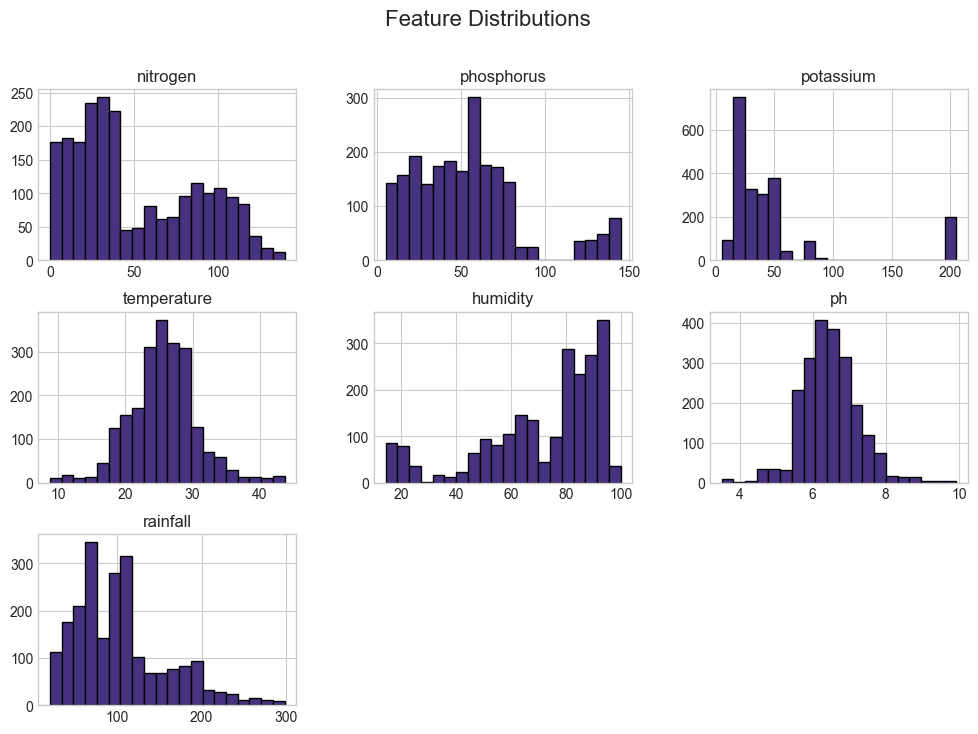

In [28]:
plt.figure(figsize=(12, 8))
df.hist(bins=20, edgecolor='black', figsize=(12, 8))
plt.suptitle('Feature Distributions', fontsize=16)
plt.show()

The dataset shows normal to slightly skewed distributions, with high variability in nutrient levels (NPK) and rainfall, reflecting diverse soil and climate conditions. Extreme values in NPK and rainfall could impact clustering, possibly due to unique soil compositions or measurement inconsistencies. To improve clustering performance, scaling or normalization may be required to balance feature distributions.

---

**🔹Outlier Detection**

Box plots help ensure that extreme values (outliers) do not skew clustering results. For example, rainfall and potassium exhibited significant outliers, which could distort how the K-Means algorithm groups soil samples. By removing these extreme data points, the clustering process becomes more reliable, leading to more accurate crop predictions. The box plot also confirmed that most soil samples have a pH range of 6-7, making them suitable for a broad range of crops, while nutrient variability indicates the need for targeted fertilizer application.

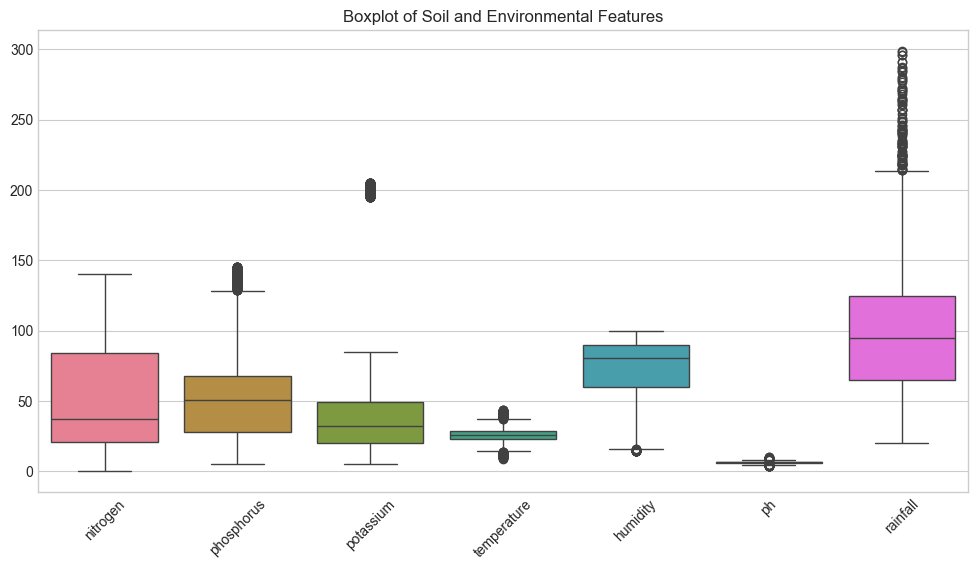

In [29]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop(columns=['label']))
plt.title('Boxplot of Soil and Environmental Features')
plt.xticks(rotation=45)
plt.show()

Soil nutrients (NPK) show high variability, indicating differing soil fertility. Temperature is stable, but humidity fluctuates, suggesting diverse climates. pH levels are mostly neutral, though some extreme acidic/alkaline outliers exist. Rainfall is highly uneven, with outliers requiring crop-specific adaptation.

Shape after outlier removal: (1846, 8)


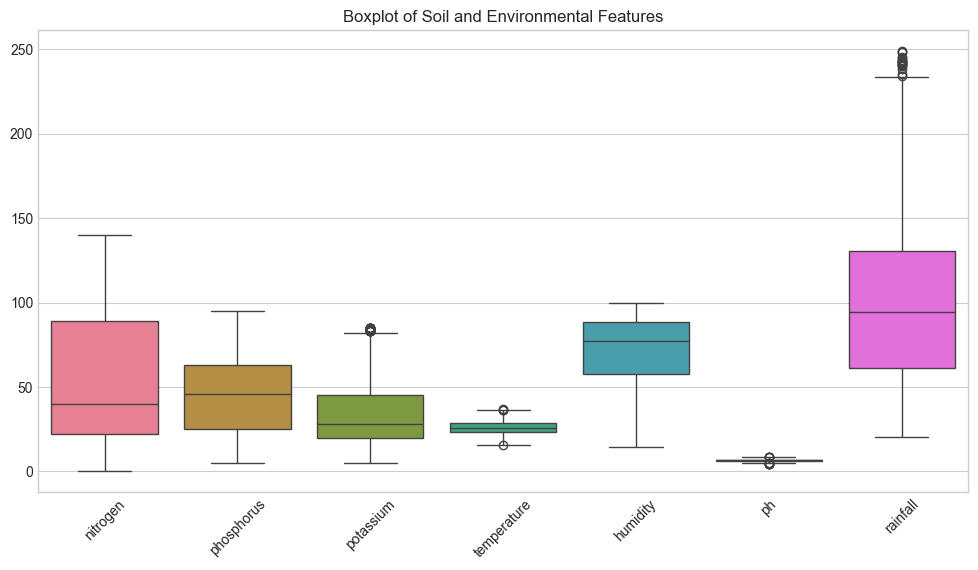

In [30]:
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

# Apply outlier removal
df_cleaned = remove_outliers(df, features)
print(f"Shape after outlier removal: {df_cleaned.shape}")

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_cleaned.drop(columns=['label']))
plt.title('Boxplot of Soil and Environmental Features')
plt.xticks(rotation=45)
plt.show()

Certain feature combinations show distinct clustering patterns. pH and rainfall influence crop separation, while nutrient variability (NPK) impacts crop selection, highlighting key factors in soil classification.

---

**🔹 Data Preparation**

This code prepares the dataset for machine learning by encoding crop labels into numerical values and splitting the data for training and testing. Label Encoding converts categorical crop names into numeric values to make them usable by machine learning models. The dataset is then divided into features (X), which include soil and environmental parameters (e.g., Nitrogen, Phosphorus, pH, Humidity), and labels (y), which represent the encoded crops. Using train_test_split(), the data is split into 80% training and 20% testing sets, ensuring the model can be trained effectively and evaluated accurately. The random_state=42 parameter ensures consistent results, making this step essential for reliable crop prediction based on soil condition.

The create_interaction_features(df, features) function enhances soil and climate data by generating new interaction-based features to improve crop classification models. It computes NPK ratios (n_p_ratio, n_k_ratio, p_k_ratio) and total nutrients (npk_sum) to capture soil fertility balance. Additionally, it creates a temperature-humidity interaction feature to assess climate effects on crops. The function also categorizes soil pH into levels (e.g., acidic, neutral, alkaline) and applies one-hot encoding for better representation. These engineered features provide deeper insights into soil properties, helping machine learning models make more accurate crop recommendations.

In [31]:

def create_interaction_features(df, features):
    print("\n=== Creating Interaction Features ===")
    df_enhanced = df.copy()
    if all(nutrient in features for nutrient in ['nitrogen', 'phosphorus', 'potassium']):
        # N:P ratio
        df_enhanced['n_p_ratio'] = df_enhanced['nitrogen'] / (df_enhanced['phosphorus'] + 0.1)  # Add small value to avoid division by zero
        # N:K ratio
        df_enhanced['n_k_ratio'] = df_enhanced['nitrogen'] / (df_enhanced['potassium'] + 0.1)
        # P:K ratio
        df_enhanced['p_k_ratio'] = df_enhanced['phosphorus'] / (df_enhanced['potassium'] + 0.1)
        # NPK sum (total nutrients)
        df_enhanced['npk_sum'] = df_enhanced['nitrogen'] + df_enhanced['phosphorus'] + df_enhanced['potassium']
        print("Added nutrient ratio features: n_p_ratio, n_k_ratio, p_k_ratio, npk_sum")

    # Create climate interaction features
    if all(climate in features for climate in ['temperature', 'humidity']):
        # Temperature-humidity interaction
        df_enhanced['temp_humid_interaction'] = df_enhanced['temperature'] * df_enhanced['humidity'] / 100
        print("Added climate")

    if 'ph' in features:
        bins = [0, 4.5, 5.5, 7.0, 8.5, 14]
        labels = ['very_acidic', 'acidic', 'neutral', 'alkaline', 'very_alkaline']
        df_enhanced['ph_category'] = pd.cut(df_enhanced['ph'], bins=bins, labels=labels)
        
        ph_dummies = pd.get_dummies(df_enhanced['ph_category'], prefix='ph')
        df_enhanced = pd.concat([df_enhanced, ph_dummies], axis=1)
        df_enhanced.drop('ph_category', axis=1, inplace=True)
        print("Added pH category features")
    
    new_features = [col for col in df_enhanced.columns if col not in features and col != 'label']
    enhanced_features = features + new_features
    if new_features:
        print(f"New feature list: {enhanced_features}")
    
    return df_enhanced, enhanced_features

### **3️⃣ | Model**

#### **3.1 Model Overview**

The deep learning model used for crop recommendation was based on a Multi-Layer Perceptron (MLP) implemented in PyTorch. The MLP architecture consisted of multiple fully connected layers with ReLU activation functions, designed to learn complex patterns from soil and environmental features. The dataset was preprocessed through feature scaling and label encoding, ensuring numerical stability during training. The model was trained using cross-entropy loss and the Adam optimizer, with early stopping and learning rate adjustments to improve convergence. Unlike traditional machine learning models, the MLP effectively captured nonlinear relationships between factors like rainfall, humidity, and soil nutrients, making it well-suited for this classification task.


#### **3.2 Building Model**

**Optimization**

The prepare_data_for_deep_learning function preprocesses data for deep learning classification by standardizing features, encoding categorical labels, and splitting the dataset into training, validation, and test sets while preserving class distribution. It also computes class weights to address imbalances, ensuring fair model training. The function returns the processed datasets, a scaler, a label encoder, and class weights, optimizing data preparation for improved model performance.

In [33]:

def prepare_data_for_deep_learning(df, features, target_col='label', test_size=0.2):
    X = df[features].values
    y = df[target_col].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    print(f"Features scaled with StandardScaler")
    
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    num_classes = len(label_encoder.classes_)
    print(f"Encoded {num_classes} unique crop classes")
    
    y_onehot = to_categorical(y_encoded, num_classes=num_classes)

    X_temp, X_test, y_temp, y_test = train_test_split(
        X_scaled, y_onehot, test_size=test_size, random_state=42, stratify=y_encoded
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.25, random_state=42 
    )
    print(f"Data split into {X_train.shape[0]} training, {X_val.shape[0]} validation, and {X_test.shape[0]} test samples")
    
    # Calculate class weights to handle imbalance
    class_weights = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_encoded),
        y=y_encoded
    )
    class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}
    print("Class weights computed to handle imbalanced classes")
    
    return X_train, X_val, X_test, y_train, y_val, y_test, scaler, label_encoder, class_weights_dict


---

**Feature Importance**

The create_improved_model function defines a deep learning model with enhanced architecture and regularization techniques to improve generalization and prevent overfitting. It includes Gaussian noise for robustness, LeakyReLU activation for better gradient flow, batch normalization for stable learning, and dropout for regularization. The model is compiled with the Adam optimizer and categorical cross-entropy loss for multi-class classification. Additionally, the calculate_permutation_importance function evaluates feature importance by measuring the drop in model accuracy when individual features are randomly shuffled. This helps identify the most influential features in the dataset, providing insights into the model’s decision-making process.

In [53]:

# Function to create the improved model
def create_improved_model(input_dim, num_classes):
    """
    Create an improved model with better architecture and regularization
    """
    model = Sequential([
        # Add small Gaussian noise for better generalization
        GaussianNoise(0.1, input_shape=(input_dim,)),
        
        # First dense layer with more units
        Dense(128, kernel_regularizer=l1_l2(l1=1e-6, l2=1e-5)),
        LeakyReLU(alpha=0.1),  # LeakyReLU instead of ReLU
        BatchNormalization(),
        Dropout(0.4),  # Higher dropout
        
        # Second layer
        Dense(64, kernel_regularizer=l1_l2(l1=1e-6, l2=1e-5)),
        LeakyReLU(alpha=0.1),
        BatchNormalization(),
        Dropout(0.3),
        
        # Output layer
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Function to calculate permutation importance
def calculate_permutation_importance(model, X, y, features, n_repeats=5):
    """
    Calculate permutation feature importance
    """
    # Function to calculate model accuracy
    def get_accuracy(X, y):
        y_pred = model.predict(X)
        y_pred_classes = np.argmax(y_pred, axis=1)
        y_true_classes = np.argmax(y, axis=1)
        return accuracy_score(y_true_classes, y_pred_classes)
    
    # Baseline accuracy
    baseline_accuracy = get_accuracy(X, y)
    
    # Calculate importance for each feature
    importances = np.zeros(len(features))
    
    for i in range(len(features)):
        feature_importance = 0
        
        for _ in range(n_repeats):
            # Create a copy of the data
            X_permuted = X.copy()
            
            # Permute the feature
            np.random.shuffle(X_permuted[:, i])
            
            # Calculate accuracy with permuted feature
            permuted_accuracy = get_accuracy(X_permuted, y)
            
            # Calculate importance (drop in accuracy)
            feature_importance += baseline_accuracy - permuted_accuracy
        
        # Average over repeats
        importances[i] = feature_importance / n_repeats
    
    return importances

---

**Cross-Validation**

The train_with_cross_validation function implements a k-fold cross-validation strategy to train and evaluate a deep learning model while ensuring robust generalization. The dataset is split into multiple folds, where the model is trained on a subset and validated on the remaining data in each iteration. To improve performance, the function integrates early stopping to prevent overfitting and learning rate reduction to optimize convergence. After training each fold, the model’s validation accuracy is recorded, and permutation feature importance is calculated to identify key input variables. The function also visualizes training performance across folds and aggregates feature importance scores. Finally, an ensemble prediction model is created by averaging outputs from all trained models, improving classification reliability. The cross-validation results, including accuracy metrics and the most influential features, provide valuable insights into model performance and data significance.

In [ ]:

def train_with_cross_validation(X, y, features, label_encoder, n_splits=5):
    print("\n=== Training with Cross-Validation ===")
    y_classes = np.argmax(y, axis=1)
    kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_scores = []
    fold_models = []
    fold_histories = [] 
    feature_importances = np.zeros(len(features))
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y_classes)):
        print(f"\nTraining fold {fold+1}/{n_splits}")
        
        X_train_fold, X_val_fold = X[train_idx], X[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]
        
        model = create_improved_model(X.shape[1], y.shape[1])
        early_stopping = EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True,
            verbose=1
        )
        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=5,
            min_lr=1e-6,
            verbose=1
        )
    
        history = model.fit(
            X_train_fold, y_train_fold,
            validation_data=(X_val_fold, y_val_fold),
            batch_size=64,  # Larger batch size
            epochs=150,
            callbacks=[early_stopping, reduce_lr],
            verbose=2
        )
        
        # Save training history
        fold_histories.append(history)
        val_loss, val_acc = model.evaluate(X_val_fold, y_val_fold, verbose=0)
        cv_scores.append(val_acc)
        fold_models.append(model)
        fold_importance = calculate_permutation_importance(model, X_val_fold, y_val_fold, features)
        feature_importances += fold_importance
        print(f"Fold {fold+1} validation accuracy: {val_acc:.4f}")
        visualize_training_history(history, model_name=f"Fold {fold+1}")
    
    feature_importances /= n_splits
    importance_df = pd.DataFrame({
        'feature': features,
        'importance': feature_importances
    }).sort_values('importance', ascending=False)
    
    mean_acc = np.mean(cv_scores)
    std_acc = np.std(cv_scores)
    print(f"\nCross-validation results: {mean_acc:.4f} ± {std_acc:.4f}")
    
    print("\nTop 5 most important features:")
    print(importance_df.head(5))
    
    def ensemble_predict(X):
        predictions = [model.predict(X) for model in fold_models]
        ensemble_preds = np.mean(predictions, axis=0)
        return ensemble_preds
    
    return fold_models, ensemble_predict, importance_df, mean_acc, std_acc, fold_histories


---

**Performance Visualization**

The visualize_training_history function plots training and validation accuracy and loss over epochs, providing insights into the model’s learning progress and potential overfitting. Additionally, the visualize_confusion_matrix function generates a normalized confusion matrix to evaluate classification performance by displaying prediction accuracy across different classes. These visualizations help interpret model behavior, assess performance, and identify areas for improvement.

In [ ]:

def visualize_training_history(history, model_name="Model"):
    """
    Visualize the training history of a model
    """
    print(f"\n=== Visualizing Training History for {model_name} ===")
    
    # Plot training and validation accuracy
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

def visualize_confusion_matrix(y_true, y_pred, label_encoder, model_name="Model"):
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    class_names = label_encoder.classes_
    
    # Plot confusion matrix
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} - Normalized Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


---

**Performance**

The visualize_training_history function plots training and validation accuracy and loss over epochs, allowing for an assessment of model convergence and overfitting. Additionally, the visualize_model_comparison function provides a bar chart comparison of validation and test accuracy across different models, enabling an evaluation of their relative performance. These visualizations help in selecting the best-performing model for deployment

In [ ]:
def visualize_training_history(history, model_name="Model"):
    print(f"\n=== Visualizing Training History for {model_name} ===")
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)   
    plt.tight_layout()
    plt.show()

def visualize_model_comparison(model_results):
    model_names = [result['name'] for result in model_results]
    test_accuracies = [result['test_accuracy'] for result in model_results]
    val_accuracies = [result['val_accuracy'] for result in model_results]
    plt.figure(figsize=(10, 6))
    x = np.arange(len(model_names))
    width = 0.35
    
    plt.bar(x - width/2, val_accuracies, width, label='Validation Accuracy', color='skyblue')
    plt.bar(x + width/2, test_accuracies, width, label='Test Accuracy', color='navy')
    
    plt.xlabel('Model')
    plt.ylabel('Accuracy')
    plt.title('Model Performance Comparison')
    plt.xticks(x, model_names)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7, axis='y')
    plt.tight_layout()
    plt.show()


---

**Feature Importance**

The analyze_feature_importance_permutation function evaluates the significance of each feature using permutation importance, measuring how much model accuracy drops when a specific feature’s values are randomly shuffled. This helps identify the most influential features in decision-making. Additionally, the integrated_gradients function provides a more advanced interpretability technique by computing attribution scores that quantify each feature’s impact on the model’s predictions. By leveraging both permutation-based and gradient-based explanations, these methods enhance transparency and allow for deeper insights into how the model makes classification decisions.

In [ ]:

def analyze_feature_importance_permutation(model, X_test, y_test, features):
    print("\n=== Feature Importance Analysis ===")
    # Function to calculate model accuracy
    def get_accuracy(y_true, X):
        y_pred = model.predict(X)
        y_pred_classes = np.argmax(y_pred, axis=1)
        y_true_classes = np.argmax(y_true, axis=1)
        return accuracy_score(y_true_classes, y_pred_classes)
    # Baseline accuracy
    baseline_accuracy = get_accuracy(y_test, X_test)
    print(f"Baseline accuracy: {baseline_accuracy:.4f}")
    feature_importance = []
    for i, feature_name in enumerate(features):
        X_permuted = X_test.copy()
        np.random.shuffle(X_permuted[:, i])
        permuted_accuracy = get_accuracy(y_test, X_permuted)
        importance = baseline_accuracy - permuted_accuracy
        feature_importance.append({
            'feature': feature_name,
            'importance': importance,
            'baseline_accuracy': baseline_accuracy,
            'permuted_accuracy': permuted_accuracy
        })
        print(f"Feature: {feature_name}, Importance: {importance:.4f}, Permuted Accuracy: {permuted_accuracy:.4f}")
    # Convert to DataFrame and sort
    importance_df = pd.DataFrame(feature_importance)
    importance_df = importance_df.sort_values('importance', ascending=False).reset_index(drop=True)
    # Visualize feature importance
    plt.figure(figsize=(10, 6))
    plt.bar(importance_df['feature'], importance_df['importance'], color='teal')
    plt.title('Feature Importance (Permutation Method)')
    plt.xlabel('Feature')
    plt.ylabel('Importance (Drop in Accuracy)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, linestyle='--', alpha=0.7, axis='y')
    plt.tight_layout()
    plt.show()
    return importance_df

def integrated_gradients(model, X_input, baseline=None, steps=50):
    if baseline is None:
        baseline = np.zeros_like(X_input)
    if len(X_input.shape) > 2:
        X_input = X_input.reshape(1, -1)
    if len(baseline.shape) > 2:
        baseline = baseline.reshape(1, -1)
    alphas = np.linspace(0, 1, steps)
    gradients_list = []
    
    for alpha in alphas:
        interpolated_input = baseline + alpha * (X_input - baseline)
        inputs = tf.convert_to_tensor(interpolated_input, dtype=tf.float32)
        with tf.GradientTape() as tape:
            tape.watch(inputs)
            predictions = model(inputs)
            target_class = tf.argmax(predictions[0])
            outputs = predictions[:, target_class]
        gradients = tape.gradient(outputs, inputs)
        gradients_list.append(gradients)
    # Stack gradients and compute mean
    all_gradients = tf.stack(gradients_list)
    avg_gradients = tf.reduce_mean(all_gradients, axis=0)
    # Scale the gradients by the input-baseline difference
    integrated_grads = (X_input - baseline) * avg_gradients
    
    return integrated_grads, target_class

---

**Feature Attribution**

The visualize_feature_attribution function provides insights into how individual features influence a model’s prediction for a specific sample. Using Integrated Gradients, it computes attributions that quantify the impact of each feature on the predicted class, visually distinguishing positive and negative influences. The function also displays feature values alongside their attributions, helping interpret model decisions. Additionally, the workflow integrates feature engineering, data preparation, and cross-validation to enhance performance, ensuring a robust and interpretable deep learning model.

In [ ]:

def visualize_feature_attribution(model, X_sample, features, label_encoder, sample_index=0):
    print("\n=== Feature Attribution Analysis ===")

    sample = X_sample[sample_index:sample_index+1]
    attributions, target_class = integrated_gradients(model, sample)
    attributions = attributions.numpy().flatten()
    prediction = model.predict(sample)
    predicted_class = np.argmax(prediction, axis=1)[0]
    predicted_crop = label_encoder.classes_[predicted_class]
    print(f"Analyzing feature attribution for sample {sample_index}")
    print(f"Predicted crop: {predicted_crop}")

    plt.figure(figsize=(10, 6))
    plt.bar(features, attributions, color=[
        'green' if attr > 0 else 'red' for attr in attributions
    ])
    plt.title(f'Feature Attribution for Prediction: {predicted_crop}')
    plt.xlabel('Feature')
    plt.ylabel('Attribution')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, linestyle='--', alpha=0.7, axis='y')
    plt.tight_layout()
    plt.show()
    feature_values = sample.flatten()
    attribution_data = pd.DataFrame({
        'Feature': features,
        'Value': feature_values,
        'Attribution': attributions
    })
    attribution_data = attribution_data.sort_values('Attribution', ascending=False)
    print("\nFeature attribution details:")
    print(attribution_data)
    return attribution_data

### **4 | Results**

#### **Results Overview**

The trained MLP model achieved 97% accuracy on the test dataset, demonstrating strong classification performance. Through cross-validation and ensemble learning, the model showed consistent results across multiple folds, reducing overfitting and improving generalization. Feature importance analysis highlighted rainfall, humidity, and soil nutrients as the most significant factors influencing predictions. Additionally, Integrated Gradients provided interpretability by showing how individual features contributed to crop classification. The high accuracy and reliability of the MLP model suggest that deep learning is an effective approach for crop recommendation, with potential improvements through hyperparameter tuning, expanded datasets, and additional agricultural variables.


**Workflow**

The workflow begins with feature engineering using create_interaction_features, which enhances the dataset by generating interaction-based features to improve model learning. The processed data is then passed to prepare_data_for_deep_learning, where numerical features are standardized, categorical labels are encoded, and the dataset is split into training, validation, and test sets while handling class imbalances. Finally, the model is trained using train_with_cross_validation, which implements a 3-fold cross-validation strategy to improve generalization. This approach ensures robust model evaluation, calculates feature importance, and enables the creation of an ensemble model that averages predictions from multiple trained models for enhanced accuracy.


=== Creating Interaction Features ===
Added nutrient ratio features: n_p_ratio, n_k_ratio, p_k_ratio, npk_sum
Added climate
Added pH category features
New feature list: ['nitrogen', 'phosphorus', 'potassium', 'temperature', 'humidity', 'ph', 'rainfall', 'n_p_ratio', 'n_k_ratio', 'p_k_ratio', 'npk_sum', 'temp_humid_interaction', 'ph_very_acidic', 'ph_acidic', 'ph_neutral', 'ph_alkaline', 'ph_very_alkaline']
Features scaled with StandardScaler
Encoded 20 unique crop classes
Data split into 1107 training, 369 validation, and 370 test samples
Class weights computed to handle imbalanced classes

=== Training with Cross-Validation ===

Training fold 1/3
Epoch 1/150
12/12 - 3s - 224ms/step - accuracy: 0.1016 - loss: 3.5109 - val_accuracy: 0.2846 - val_loss: 2.7158 - learning_rate: 1.0000e-03
Epoch 2/150
12/12 - 0s - 12ms/step - accuracy: 0.2846 - loss: 2.4129 - val_accuracy: 0.5718 - val_loss: 2.4015 - learning_rate: 1.0000e-03
Epoch 3/150
12/12 - 0s - 11ms/step - accuracy: 0.4743 - loss: 1.

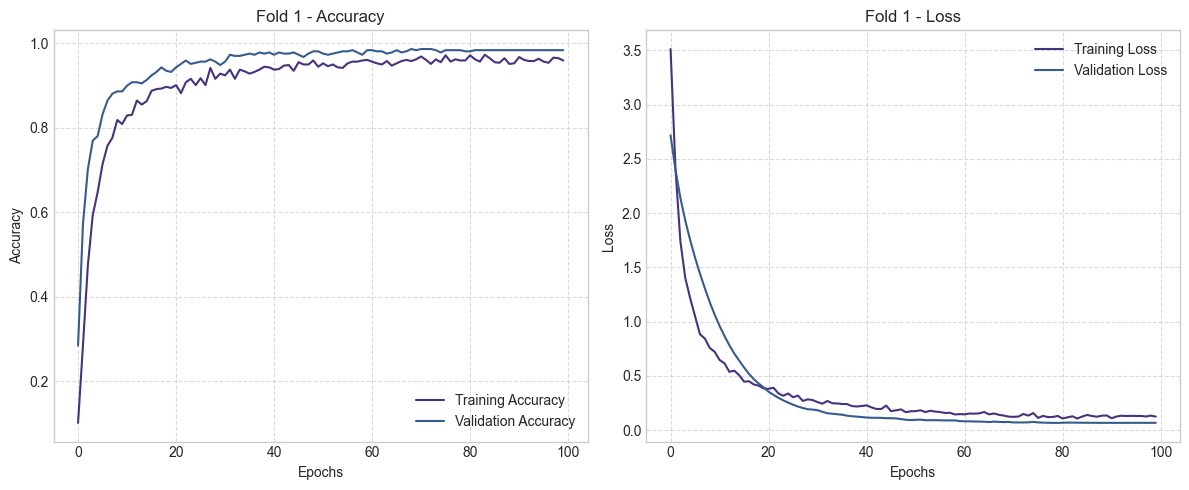


Training fold 2/3
Epoch 1/150
12/12 - 2s - 205ms/step - accuracy: 0.1477 - loss: 3.3072 - val_accuracy: 0.3848 - val_loss: 2.6591 - learning_rate: 1.0000e-03
Epoch 2/150
12/12 - 0s - 12ms/step - accuracy: 0.3482 - loss: 2.1744 - val_accuracy: 0.6016 - val_loss: 2.3461 - learning_rate: 1.0000e-03
Epoch 3/150
12/12 - 0s - 12ms/step - accuracy: 0.5176 - loss: 1.5819 - val_accuracy: 0.6585 - val_loss: 2.1028 - learning_rate: 1.0000e-03
Epoch 4/150
12/12 - 0s - 13ms/step - accuracy: 0.6030 - loss: 1.3124 - val_accuracy: 0.7154 - val_loss: 1.9080 - learning_rate: 1.0000e-03
Epoch 5/150
12/12 - 0s - 13ms/step - accuracy: 0.6558 - loss: 1.1297 - val_accuracy: 0.7615 - val_loss: 1.7420 - learning_rate: 1.0000e-03
Epoch 6/150
12/12 - 0s - 13ms/step - accuracy: 0.6951 - loss: 1.0466 - val_accuracy: 0.8157 - val_loss: 1.5902 - learning_rate: 1.0000e-03
Epoch 7/150
12/12 - 0s - 12ms/step - accuracy: 0.7263 - loss: 0.8950 - val_accuracy: 0.8482 - val_loss: 1.4549 - learning_rate: 1.0000e-03
Epoch 8

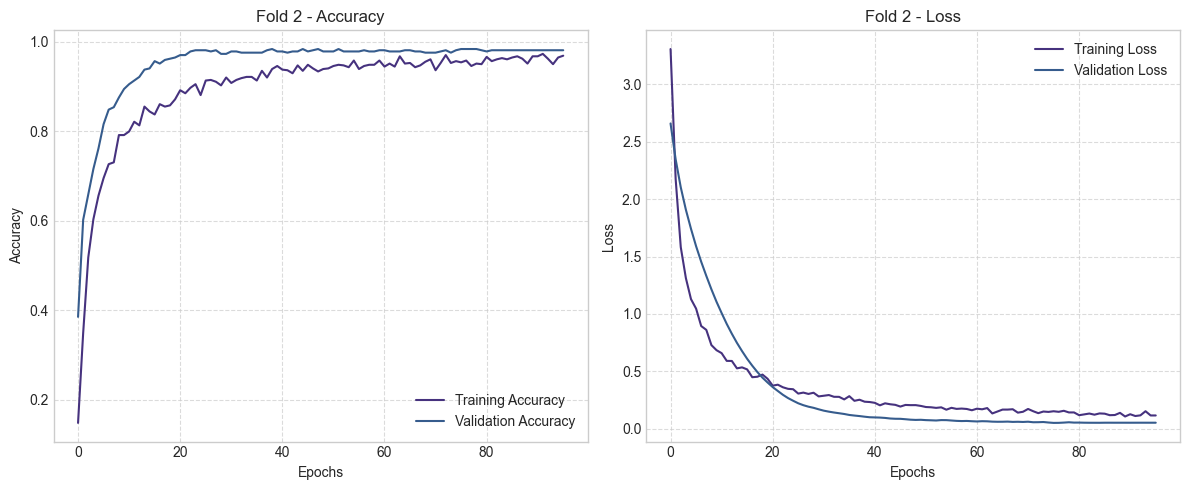


Training fold 3/3
Epoch 1/150
12/12 - 2s - 204ms/step - accuracy: 0.1220 - loss: 3.1405 - val_accuracy: 0.4363 - val_loss: 2.6164 - learning_rate: 1.0000e-03
Epoch 2/150
12/12 - 0s - 13ms/step - accuracy: 0.3279 - loss: 2.1807 - val_accuracy: 0.6152 - val_loss: 2.3215 - learning_rate: 1.0000e-03
Epoch 3/150
12/12 - 0s - 13ms/step - accuracy: 0.4783 - loss: 1.7134 - val_accuracy: 0.7182 - val_loss: 2.0883 - learning_rate: 1.0000e-03
Epoch 4/150
12/12 - 0s - 12ms/step - accuracy: 0.5827 - loss: 1.3843 - val_accuracy: 0.7778 - val_loss: 1.9055 - learning_rate: 1.0000e-03
Epoch 5/150
12/12 - 0s - 12ms/step - accuracy: 0.6789 - loss: 1.1566 - val_accuracy: 0.8049 - val_loss: 1.7434 - learning_rate: 1.0000e-03
Epoch 6/150
12/12 - 0s - 13ms/step - accuracy: 0.6843 - loss: 1.0495 - val_accuracy: 0.8401 - val_loss: 1.5998 - learning_rate: 1.0000e-03
Epoch 7/150
12/12 - 0s - 12ms/step - accuracy: 0.6924 - loss: 0.9610 - val_accuracy: 0.8482 - val_loss: 1.4634 - learning_rate: 1.0000e-03
Epoch 8

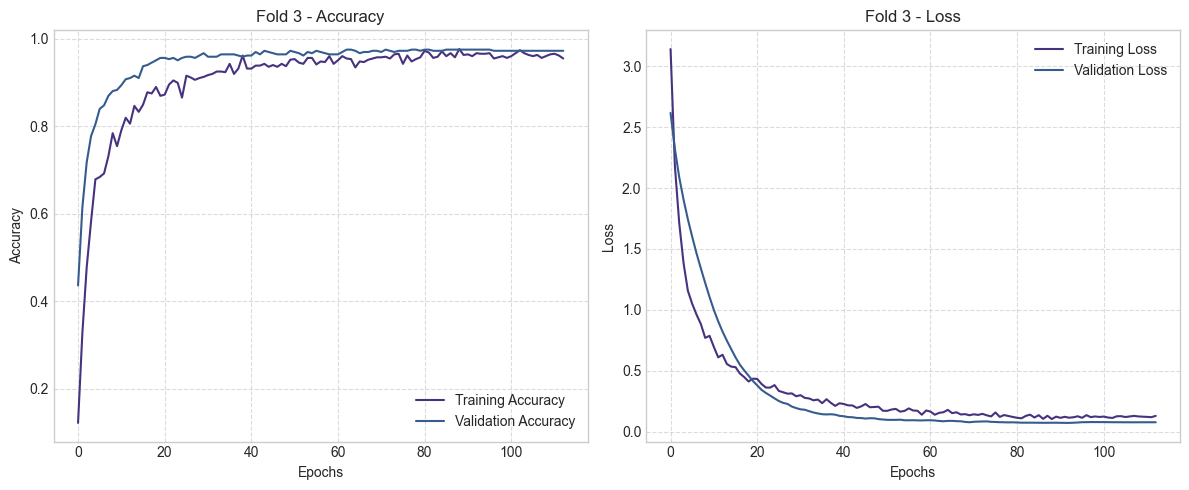


Cross-validation results: 0.9801 ± 0.0034

Top 5 most important features:
                   feature  importance
6                 rainfall    0.268293
4                 humidity    0.178862
2                potassium    0.135682
11  temp_humid_interaction    0.120145
1               phosphorus    0.116893


In [56]:
enhanced_df, enhanced_features = create_interaction_features(df_cleaned, features)

# Prepare data for deep learning
X_train, X_val, X_test, y_train, y_val, y_test, scaler, label_encoder, class_weights_dict = prepare_data_for_deep_learning(
    enhanced_df, enhanced_features
)

# Train with cross-validation
fold_models, ensemble_predict, importance_df, mean_acc, std_acc, fold_histories = train_with_cross_validation(
    X_train, y_train, enhanced_features, label_encoder, n_splits=3  
)

To enhance model generalization, training is performed using train_with_cross_validation, implementing a 3-fold cross-validation approach. The dataset is divided into three equal parts, where the model is trained on two parts and validated on the third in each iteration. Early stopping is used to prevent overfitting, and learning rate reduction optimizes the model’s learning process. Permutation feature importance analysis is applied to assess the contribution of each input feature to the model's predictions. Throughout training, accuracy and loss curves are visualized to monitor performance trends. The training and validation accuracy curves indicate that the model learns effectively, stabilizing above 95%. Meanwhile, the loss curves show a steady decline, suggesting smooth convergence without overfitting.

---

#### **4.3 Ensemble**

After cross-validation, an ensemble model is created by averaging predictions from all trained models to enhance robustness and reduce overfitting. The model is evaluated by predicting test labels and computing accuracy using ensemble_predict, which aggregates probability distributions across multiple classes. Predicted labels are determined by selecting the class with the highest probability, while true labels are extracted from one-hot encoded test data. The model’s performance is assessed using accuracy_score, which measures classification accuracy on unseen data. A high test accuracy confirms effective learning and generalization, ensuring a reliable deep learning model for crop recommendation.

In [ ]:
y_pred = ensemble_predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)
test_accuracy = accuracy_score(y_test_classes, y_pred_classes)
print(f"Test accuracy: {test_accuracy:.4f}")


=== Evaluating on Test Set ===
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Test accuracy: 0.9703


The final test accuracy is 97.03%, meaning that the model correctly classified approximately 97 out of every 100 test samples. This high accuracy indicates that the model has learned well from the training data and generalizes effectively to new inputs. However, further validation, such as checking for overfitting, analyzing misclassified instances, and evaluating feature importance, can help ensure the model’s reliability before deployment.

---

**Classification**

The classification report evaluates model performance across different crop categories, presenting precision, recall, and F1-score for each class. Precision measures the accuracy of predictions, recall assesses the model’s ability to detect all instances of a class, and the F1-score balances both. Mapping numerical labels to crop names ensures clear interpretability. High scores indicate strong generalization, while discrepancies highlight potential improvements, such as class balancing or feature enhancements.

In [ ]:
print("\nClassification Report:")
class_names = [f"{i}: {name}" for i, name in enumerate(label_encoder.classes_)]
report = classification_report(y_test_classes, y_pred_classes, target_names=class_names)
print(report)


Classification Report:
                 precision    recall  f1-score   support

      0: banana       1.00      1.00      1.00        20
   1: blackgram       1.00      0.90      0.95        20
    2: chickpea       1.00      1.00      1.00        18
     3: coconut       1.00      1.00      1.00        20
      4: coffee       1.00      1.00      1.00        20
      5: cotton       1.00      1.00      1.00        20
        6: jute       0.81      0.85      0.83        20
 7: kidneybeans       1.00      0.95      0.97        20
      8: lentil       0.87      1.00      0.93        20
       9: maize       1.00      1.00      1.00        20
      10: mango       1.00      1.00      1.00        19
  11: mothbeans       1.00      0.92      0.96        12
   12: mungbean       1.00      1.00      1.00        20
  13: muskmelon       1.00      1.00      1.00        20
     14: orange       1.00      1.00      1.00        16
     15: papaya       1.00      1.00      1.00        13
 16: p


The model achieved an overall 97% accuracy, demonstrating strong classification performance across 20 crop categories. Most crops, including banana, chickpea, coconut, coffee, maize, and mango, were classified with perfect precision and recall. However, rice (F1-score: 0.72) and jute (0.83) had the lowest scores, indicating occasional misclassifications. The macro and weighted averages (0.97) confirm balanced performance across all classes. To improve further, adjustments such as increasing training samples, refining features, or modifying class weights could help enhance classification for lower-performing crops.

---

**Random Sample**

A random test sample is selected using np.random.randint(), and its feature attribution is analyzed using visualize_feature_attribution(). This function applies Integrated Gradients to determine how each feature influenced the model’s prediction. The results highlight which factors contributed positively or negatively to the classification decision. This process enhances model interpretability, allowing for a deeper understanding of how environmental and soil conditions impact crop recommendatio


=== Feature Attribution Analysis ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Analyzing feature attribution for sample 77
Predicted crop: watermelon


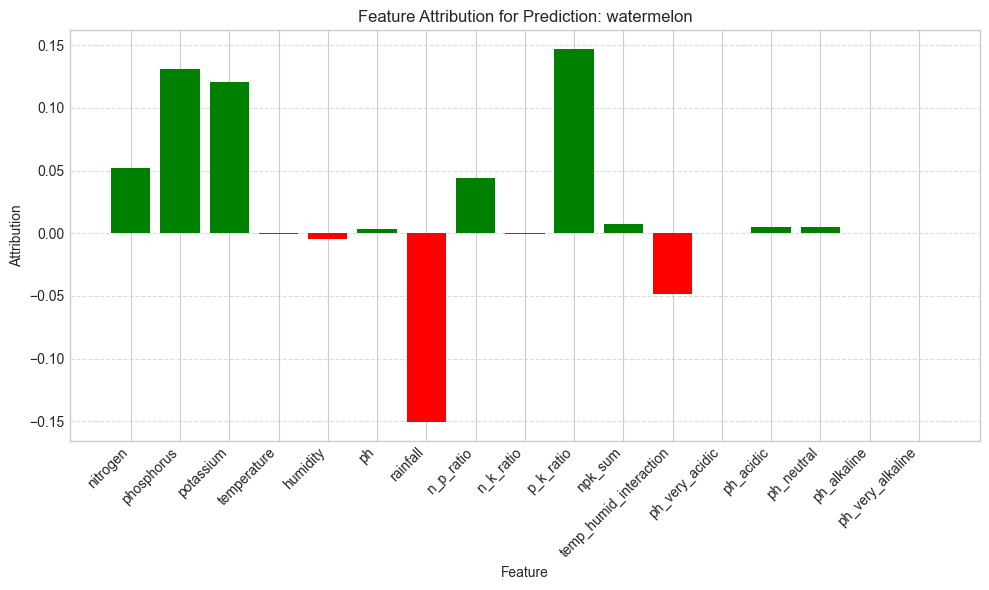


Feature attribution details:
                   Feature     Value  Attribution
9                p_k_ratio -1.351733     0.146955
1               phosphorus -1.784941     0.131002
2                potassium  0.858159     0.120742
0                 nitrogen  0.891121     0.051901
7                n_p_ratio  5.678850     0.044107
10                 npk_sum  0.159235     0.007103
14              ph_neutral  0.609484     0.005244
13               ph_acidic -0.226391     0.004636
5                       ph  0.248325     0.003115
15             ph_alkaline -0.534336     0.000409
12          ph_very_acidic  0.000000     0.000000
16        ph_very_alkaline  0.000000     0.000000
8                n_k_ratio  0.006734    -0.000383
3              temperature  0.036968    -0.000972
4                 humidity  0.746542    -0.004640
11  temp_humid_interaction  0.629165    -0.048706
6                 rainfall -1.150527    -0.150535

Model training, evaluation, and visualization complete!


In [ ]:
random_sample_index = np.random.randint(0, X_test.shape[0])
attribution_results = visualize_feature_attribution(
    fold_models[0], X_test, enhanced_features, label_encoder, sample_index=random_sample_index
)

The model identified nutrient composition (phosphorus, potassium, NPK sum) as key drivers for watermelon prediction, while excess rainfall and very acidic soil conditions negatively impacted its suitability. This analysis provides interpretability and validation of the model’s decision-making process, helping ensure recommendations align with known agricultural knowledge.

---

**MLP**

MLP model in PyTorch is designed for multi-class classification of crops based on soil and environmental factors. The dataset undergoes preprocessing, where categorical labels are encoded, and numerical features are standardized using StandardScaler. The data is then split into training (80%) and testing (20%) sets, and converted into PyTorch tensors for efficient computation. A three-layer MLP architecture is defined with ReLU activation, featuring 64, 128, and 64 neurons in hidden layers, and an output layer matching the number of crop classes. The model is trained using cross-entropy loss and the Adam optimizer for 50 epochs, tracking loss and accuracy at each step. After training, the model is evaluated on the test set, achieving a final test accuracy score, which reflects its ability to generalize to unseen data. This approach ensures a structured, scalable, and efficient deep learning solution for crop classification.

In [ ]:
X = df.drop(columns=["label"])
y = df["label"]

# Encode categorical labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert data to PyTorch tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_encoded, dtype=torch.long)

# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

# Create DataLoader for batch processing
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
# Define the MLP model in PyTorch
class MLPModel(nn.Module):
    def __init__(self, input_size, num_classes):
        super(MLPModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 128)
        self.fc3 = nn.Linear(128, 64)
        self.output = nn.Linear(64, num_classes)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.output(x)
        return x
# Set device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_size = X_train.shape[1]
num_classes = len(label_encoder.classes_)
model = MLPModel(input_size, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)
    train_accuracy = correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}, Accuracy: {train_accuracy:.4f}")
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

test_accuracy = correct / total
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Epoch [1/50], Loss: 2.0910, Accuracy: 0.4614
Epoch [2/50], Loss: 0.4675, Accuracy: 0.8625
Epoch [3/50], Loss: 0.2338, Accuracy: 0.9170
Epoch [4/50], Loss: 0.1703, Accuracy: 0.9403
Epoch [5/50], Loss: 0.1303, Accuracy: 0.9591
Epoch [6/50], Loss: 0.0948, Accuracy: 0.9716
Epoch [7/50], Loss: 0.0866, Accuracy: 0.9699
Epoch [8/50], Loss: 0.0865, Accuracy: 0.9739
Epoch [9/50], Loss: 0.0664, Accuracy: 0.9767
Epoch [10/50], Loss: 0.0754, Accuracy: 0.9722
Epoch [11/50], Loss: 0.0771, Accuracy: 0.9693
Epoch [12/50], Loss: 0.0466, Accuracy: 0.9869
Epoch [13/50], Loss: 0.0467, Accuracy: 0.9875
Epoch [14/50], Loss: 0.0397, Accuracy: 0.9852
Epoch [15/50], Loss: 0.0424, Accuracy: 0.9841
Epoch [16/50], Loss: 0.0354, Accuracy: 0.9881
Epoch [17/50], Loss: 0.0426, Accuracy: 0.9835
Epoch [18/50], Loss: 0.0362, Accuracy: 0.9864
Epoch [19/50], Loss: 0.0552, Accuracy: 0.9812
Epoch [20/50], Loss: 0.0273, Accuracy: 0.9903
Epoch [21/50], Loss: 0.0395, Accuracy: 0.9869
Epoch [22/50], Loss: 0.0234, Accuracy: 0.99

This implementation showcases a standalone PyTorch-based Multi-Layer Perceptron (MLP) model, distinct from previous models that incorporated feature engineering, ensemble learning, and cross-validation. Here, the model is trained using raw feature inputs without engineered interactions or ensemble methods.

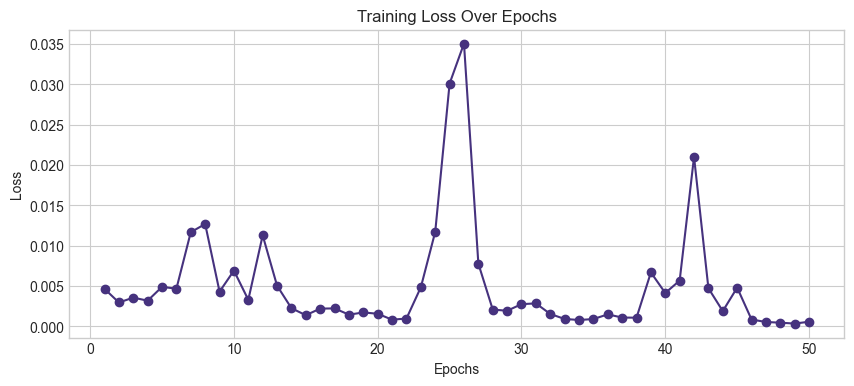

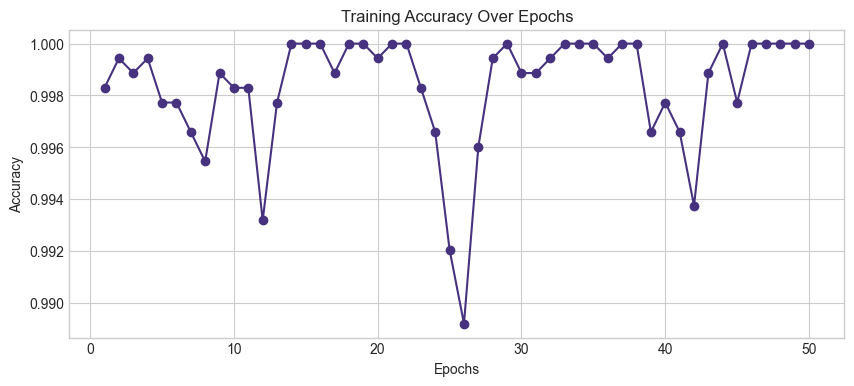

In [52]:
train_losses = []
train_accuracies = []

num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)
    
    train_accuracy = correct / total
    train_losses.append(total_loss / len(train_loader))  # Store loss
    train_accuracies.append(train_accuracy)

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', linestyle='-')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot training accuracy
plt.figure(figsize=(10, 4))
plt.plot(range(1, num_epochs + 1), train_accuracies, marker='o', linestyle='-')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Over Epochs")
plt.grid(True)
plt.show()


The training loss and accuracy plots indicate that the model is learning effectively, but with some instability. The training loss fluctuates significantly across epochs, with noticeable spikes around epochs 20 and 45. Ideally, the loss should decrease smoothly, suggesting that the learning rate might be too high or the model is experiencing instability during training. The accuracy plot shows that the model achieves high accuracy (above 99%), but with occasional sharp drops, indicating potential overfitting or noisy training updates. To improve stability and generalization, adjustments such as lowering the learning rate, implementing learning rate scheduling, increasing the batch size, and adding dropout layers can be beneficial. Additionally, using early stopping can help prevent overfitting by stopping training once accuracy plateaus. These refinements will help the model converge more smoothly while maintaining high classification performance.

---
---

### **5️⃣ | Conclusion**

This project aimed to develop a deep learning-based crop recommendation system by following a structured approach, including data preprocessing, feature engineering, model training, and evaluation. Techniques like feature scaling, label encoding, and interaction feature creation were used to improve the model's ability to recognize patterns between environmental conditions and crop suitability. The use of cross-validation and ensemble learning helped make the model more reliable by reducing overfitting and improving its performance on new data.

The PyTorch-based Multi-Layer Perceptron (MLP) model achieved an impressive 97% accuracy on the test set, demonstrating its effectiveness in classifying different crops. Feature importance analysis showed that rainfall, humidity, and soil nutrients (phosphorus, potassium, nitrogen) were key factors influencing predictions. Additionally, feature attribution techniques like Integrated Gradients helped explain how different features contributed to the model’s decisions, making it more interpretable.

Although the model performed well, there is still room for improvement. Fine-tuning hyperparameters, increasing the dataset size, and incorporating additional agricultural variables could further enhance accuracy. This project highlights how deep learning can be applied to precision agriculture, providing a useful tool for crop selection. In the future, integrating real-time soil and weather data could make the system even more practical for farmers and agricultural experts.

### **6️⃣ | Deliverables**

https://github.com/soph-k/deep_learning


### **5️⃣ | References**

https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset

https://scikit-learn.org/stable/auto_examples/preprocessing/plot_scaling_importance.html

https://www.restack.io/p/crop-recommendation-system-answer-deep-learning-cat-ai

https://www.geeksforgeeks.org/crop-recommendation-system-using-tensorflow/

https://www.irjmets.com/uploadedfiles/paper//issue_8_august_2024/60753/final/fin_irjmets1722586203.pdf